# D1Q5 ZOT

In [214]:
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
#-------------------------------------------------Símbolos----------------------------------------------
omega, rho, w, theta, d = symbols('omega, \\rho, w, \\theta, \\partial')
ux, uy, tauxx, tauxy, tauyy = symbols('u^{*}_{x} u^{*}_{y} \\tau^{*}_{xx} \\tau^{*}_{xy} \\tau^{*}_{yy}')
wi, cx, cy, css = symbols('w_{i} c_{x} c_{y} c_{s}')
#--------------------------------------Simbolos--Buckley--Model--------------------------------------------
b, sxx, s, lan, La, Pi, Pi4 = symbols('B_{\\alpha} s_{xx} s_{k} \\lambda \\Lambda_{\\alpha\\beta} \\Pi_{\\alpha\\beta\\gamma} \\Pi_{\\alpha\\beta\\gamma\\delta}')
#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)
cx5=np.array([0,1,-1,3,-3])
wi5z=np.array([(16+4*sp.sqrt(10))/45,(24-3*sp.sqrt(10))/80,(24-3*sp.sqrt(10))/80,(16-5*sp.sqrt(10))/720,(16-5*sp.sqrt(10))/720])
#-------------------------------------------------Nonorthogonal central moment----------------------------
as2 = 1/(1-sqrt(Rational(2,5)))
cs =1/ sqrt(as2)
gamma=(16+5*sqrt(10))/6
#-------------------------------------------------Calc.Func------------------------------------------------
feq5= rho*wi5z *(1 + as2*cx5*ux 
            +(as2**2)*(ux*ux + (theta-1)/as2)*(cx5*cx5 - 1/as2) /2
            +(as2**3)*(ux*ux*ux + (theta-1)*3*ux/as2)*(cx5*cx5*cx5 - 3*cx5/as2)/6    
            +(as2**4)*(ux*ux*ux*ux + (theta-1)*6*ux*ux/as2 + 3*((theta-1)**2)/(as2**2))*(cx5*cx5*cx5*cx5-6*cx5*cx5/as2 + 3/(as2**2))/24/gamma
        )

In [218]:
display(simplify(sum(feq5)))
display(simplify(sum(feq5*cx5)))
display(collect(simplify(sum(feq5*(cx5*cx5))),{rho*theta}).subs(-1/as2,css**2))
display(collect(simplify(sum(feq5*(cx5*cx5*cx5))),{rho*theta*ux}).subs(-3/as2,3*css**2))
display(collect(simplify(sum(feq5*cx5*cx5*cx5*cx5)),{rho*theta*ux*ux,rho*theta*theta}).subs(simplify(6/as2),6*css**2)
       .subs(6*css**2-Rational(9,5),3*css**4))

\rho

\rho*u^{*}_{x}

-\rho*\theta*c_{s}**2 + \rho*u^{*}_{x}**2

-3*\rho*\theta*c_{s}**2*u^{*}_{x} + \rho*u^{*}_{x}**3

3*\rho*\theta**2*c_{s}**4 + 6*\rho*\theta*c_{s}**2*u^{*}_{x}**2 + \rho*u^{*}_{x}**4

In [199]:
display(simplify(sum(feq5)))
display(simplify(sum(feq5*cx5)))
display(collect(simplify(sum(feq5*(cx5*cx5-cs*cs))),{rho*theta,rho}).subs(-1/as2,-css**2))
display(collect(simplify(sum(feq5*(cx5*cx5*cx5-3*cx5*cs**2))),{rho*theta*ux,rho*ux}).subs(-3/as2,-3*css**2))
mm4=collect(simplify(sum(feq5*(cx5*cx5*cx5*cx5-6*cx5*cx5*cs**2+3*cs**4))),{rho*theta*ux*ux,
                                                                               rho*theta*theta,
                                                                              rho*theta,
                                                                              rho*ux**2,
                                                                              rho})
mm42=collect(simplify(mm4/gamma),{rho*theta*ux*ux,rho*theta*theta,rho*theta,rho*ux**2,rho})
display(mm42.subs(simplify(6/as2),6*css**2)
            .subs(6*css**2-Rational(9,5),3*css**4)
            .subs(simplify(-6/as2**2),-6*css**4)
            .subs(-3*css**4-Rational(9,5),-6*css**2))

\rho

\rho*u^{*}_{x}

\rho*\theta*c_{s}**2 + \rho*(-c_{s}**2 + u^{*}_{x}**2)

3*\rho*\theta*c_{s}**2*u^{*}_{x} + \rho*u^{*}_{x}*(-3*c_{s}**2 + u^{*}_{x}**2)

3*\rho*\theta**2*c_{s}**4 - 6*\rho*\theta*c_{s}**4 + 6*\rho*\theta*c_{s}**2*u^{*}_{x}**2 + 3*\rho*c_{s}**4 + \rho*u^{*}_{x}**2*(-6*c_{s}**2 + u^{*}_{x}**2)

# D2Q25 ZOT

In [51]:
from pylab import *
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
from matplotlib import pyplot as plt 
from IPython.display import display, Math, Latex
#-------------------------------------------------Símbolos----------------------------------------------
rho, theta, rk = symbols('\\rho, \\theta, r_{k}')
ux, uy = symbols('u^{*}_{x} u^{*}_{y}')
wi, cx, cy, cs = symbols('w_{i} c_{x} c_{y} c_{s}')

#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)
#-------------------------------------------------Variávcs----------------------------------------------
sqrt_10 = sqrt(10)
aux0 = 4*(4+sqrt_10)/45
aux1 = 3*(8-sqrt_10)/80
aux3 = (16-5*sqrt_10)/720

w00 = aux0*aux0
w01 = aux0*aux1
w11 = aux1*aux1
w03 = aux0*aux3
w13 = aux1*aux3
w33 = aux3*aux3

as2 = 1/(1-sqrt(Rational(2,5)))

gamma=(16+5*sqrt(10))/6

wi=np.array([w00, w01, w01, w01, w01, w11, w11, w11, w11, w03, w03, w03, w03, w13, w13, w13, w13, w13, w13, w13, w13, w33, w33, w33, w33])
cx=np.array([0, 1, 0, -1, 0, 1, -1, -1, 1, 3, 0, -3, 0, 3, 1, -1, -3, -3, -1, 1, 3, 3, -3, -3, 3])
cy=np.array([0, 0, 1, 0, -1, 1, 1, -1, -1, 0, 3, 0, -3, 1, 3, 3, 1, -1, -3, -3, -1, 3, 3, -3, -3])

Hxxxxyy=(cx**4*cy**2 - (cx**4+6*cx**2*cy**2)/as2 + (6*cx**2+3*cy**2)/as2**2 - 3/as2**3)
Mxxxxyy=(3*(theta/as2)**3-9*theta**2/as2**3+6*theta**2*ux*ux/as2**2+3*theta**2*uy*uy/as2**2+9*theta/as2**3-12*theta*ux*ux/as2**2
        -6*theta*uy*uy/as2**2 +theta*ux**4/as2+6*theta*ux*ux*uy*uy/as2 -3/as2**3+6*ux*ux/as2**2+3*uy*uy/as2**2-ux**4/as2
        -6*ux*ux*uy*uy/as2+ux**4*uy*uy)
Hxxyyyy=(cy**4*cx**2 - (cy**4+6*cx**2*cy**2)/as2 + (6*cy**2+3*cx**2)/as2**2 - 3/as2**3)
Mxxyyyy=(3*(theta/as2)**3-9*theta**2/as2**3+6*theta**2*uy*uy/as2**2+3*theta**2*ux*ux/as2**2+9*theta/as2**3-12*theta*uy*uy/as2**2
        -6*theta*ux*ux/as2**2 +theta*uy**4/as2+6*theta*ux*ux*uy*uy/as2 -3/as2**3+6*uy*uy/as2**2+3*ux*ux/as2**2-uy**4/as2
        -6*ux*ux*uy*uy/as2+uy**4*ux*ux)
Hxxxxyyy=(cx**4*cy**3 - (3*cx**4*cy+6*cx**2*cy**3)/as2 + (18*cx**2*cy+3*cy**3)/as2**2 - 9*cy/as2**3)
Mxxxxyyy=uy*(9*(theta/as2)**3-27*theta**2/as2**3+18*theta**2*ux*ux/as2**2+3*theta**2*uy*uy/as2**2+27*theta/as2**3-36*theta*ux*ux/as2**2
        -6*theta*uy*uy/as2**2 +3*theta*ux**4/as2+6*theta*ux*ux*uy*uy/as2 -9/as2**3+18*ux*ux/as2**2+3*uy*uy/as2**2-3*ux**4/as2
        -6*ux*ux*uy*uy/as2+ux**4*uy*uy)
Hxxxyyyy=(cy**4*cx**3 - (3*cy**4*cx+6*cy**2*cx**3)/as2 + (18*cy**2*cx+3*cx**3)/as2**2 - 9*cx/as2**3)
Mxxxyyyy=ux*(9*(theta/as2)**3-27*theta**2/as2**3+18*theta**2*uy*uy/as2**2+3*theta**2*ux*ux/as2**2+27*theta/as2**3-36*theta*uy*uy/as2**2
        -6*theta*ux*ux/as2**2 +3*theta*uy**4/as2+6*theta*ux*ux*uy*uy/as2 -9/as2**3+18*uy*uy/as2**2+3*ux*ux/as2**2-3*uy**4/as2
        -6*ux*ux*uy*uy/as2+uy**4*ux*ux)
Hxxxxyyyy=(cx**4*cy**4 - 6*(cx**4*cy**2+cx**2*cy**4)/as2 - 18*(cx**2+cy**2)/as2**3 + 3*(cx**4+cy**4)/as2**2 +36*cx**2*cy**2/as2**2 + 9/as2**4)
Mxxxxyyyy=(9*theta**4/as2**4 - 36*theta**3/as2**4 + 18*theta**3/as2**3*ux**2 + 18*theta**3/as2**3*uy**2 + 54*theta**2/as2**4 
           - 54*theta**2/as2**3*ux**2 - 54*theta**2/as2**3*uy**2 + 3*theta**2/as2**2*ux**4 + 36*theta**2/as2**2*ux**2*uy**2 
           + 3*theta**2/as2**2*uy**4 - 36*theta/as2**4 + 54*theta/as2**3*ux**2 + 54*theta/as2**3*uy**2 - 6*theta/as2**2*ux**4 
           - 72*theta/as2**2*ux**2*uy**2 - 6*theta/as2**2*uy**4 + 6*theta/as2*ux**4*uy**2 + 6*theta/as2*ux**2*uy**4 + 9/as2**4 
           - 18/as2**3*ux**2 - 18/as2**3*uy**2 + 3/as2**2*ux**4 + 36/as2**2*ux**2*uy**2 + 3/as2**2*uy**4 - 6/as2*ux**4*uy**2 
           - 6/as2*ux**2*uy**4 + ux**4*uy**4)
#-------------------------------------------------Calc.Func------------------------------------------------
feq6 = rho*wi *(1 + as2*(cx*ux + cy*uy) 
                
            +(as2**2)*(ux*ux + (theta-1)/as2)*(cx*cx - 1/as2) /2
            +2*(as2**2)*ux*uy*cx*cy /2
            +(as2**2)*(uy*uy + (theta-1)/as2)*(cy*cy - 1/as2)/2
                
            +(as2**3)*(ux*ux*ux + (theta-1)*3*ux/as2)*(cx*cx*cx - 3*cx/as2)/6
            +3*(as2**3)*(ux*ux*uy + (theta-1)*uy/as2)*(cx*cx*cy - cy/as2)/6
            +3*(as2**3)*(ux*uy*uy + (theta-1)*ux/as2)*(cx*cy*cy - cx/as2)/6
            +(as2**3)*(uy*uy*uy + (theta-1)*3*uy/as2)*(cy*cy*cy - 3*cy/as2)/6
               
            +(as2**4)*(ux*ux*ux*ux + (theta-1)*6*ux*ux/as2 + 3*((theta-1)**2)/(as2**2))*(cx*cx*cx*cx-6*cx*cx/as2 + 3/(as2**2))/24/gamma
            +4*(as2**4)*(ux*ux*ux*uy + (theta-1)*3*ux*uy/as2)*(cx*cx*cx*cy-3*cx*cy/as2)/24
            +6*(as2**4)*(ux*ux*uy*uy + (theta-1)*(ux*ux+uy*uy)/as2 + ((theta-1)**2)/(as2**2))*(cx*cx*cy*cy-(cx*cx+cy*cy)/as2 + 1/(as2**2))/24
            +4*(as2**4)*(ux*uy*uy*uy + (theta-1)*3*ux*uy/as2)*(cx*cy*cy*cy-3*cx*cy/as2)/24
            +(as2**4)*(uy*uy*uy*uy + (theta-1)*6*uy*uy/as2 + 3*((theta-1)**2)/(as2**2))*(cy*cy*cy*cy-6*cy*cy/as2 + 3/(as2**2))/24/gamma

            +5*(as2**5)*(ux**4*uy + (theta-1)*6*ux**2*uy/as2 + ((theta-1)**2)*3*uy/as2**2)*(cx**4*cy-6*cx**2*cy/as2 + 3*cy/as2**2)  /120/gamma
            +10*(as2**5)*(ux**3*uy**2 + (theta-1)*(3*ux*uy**2+ux**3)/as2 + ((theta-1)**2)*3*ux/as2**2)*(cx**3*cy**2-3*cx*cy**2/as2-cx**3/as2 + 3*cx/as2**2) /120 
            +10*(as2**5)*(uy**3*ux**2 + (theta-1)*(3*ux**2*uy+uy**3)/as2 + ((theta-1)**2)*3*uy/as2**2)*(cy**3*cx**2-3*cx**2*cy/as2-cy**3/as2 + 3*cy/as2**2)  /120
            +5*(as2**5)*(uy**4*ux + (theta-1)*6*uy**2*ux/as2 + ((theta-1)**2)*3*ux/as2**2)*(cy**4*cx-6*cy**2*cx/as2 + 3*cx/as2**2)  /120/gamma

            +(15*(as2**6)/720)*Mxxxxyy*Hxxxxyy/gamma
            +(20*(as2**6)/720)*(ux**3*uy**3 + 3*(theta-1)*(ux**3*uy + ux*uy**3)/as2 + 9*(theta-1)**2*ux*uy/as2**2)*(cx**3*cy**3 - 3*(cx**3*cy+cx*cy**3)/as2 + 9*cx*cy/as2**2)
            +(15*(as2**6)/720)*Mxxyyyy*Hxxyyyy/gamma

            +(35*(as2**7)/5040)*Mxxxxyyy*Hxxxxyyy/gamma
            +(35*(as2**7)/5040)*Mxxxyyyy*Hxxxyyyy/gamma

            +(70*(as2**8)/40320)*Mxxxxyyyy*Hxxxxyyyy/gamma**2
        )

# $f_{i}^{(6)}$: $\mathcal{H}^{0}$, $\mathcal{H}^{1}_{\alpha}$, $\mathcal{H}^{2}_{\alpha\beta}$

In [53]:
a0=simplify(sum(feq6))
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(0)}_{i} \quad = \quad a^{(0)}_{eq} \quad = \quad '+ sp.latex(a0)))
ax=simplify(sum(feq6*cx))
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(1)}_{i,x} \quad = \quad a^{(1)}_{eq,x} \quad = \quad '+ sp.latex(ax)))
axx=collect(expand(simplify(sum(feq6*cx*cx))),rho*theta).subs(simplify(1/as2),cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(2)}_{i,xx} \quad = \quad a^{(2)}_{eq,xx} \quad = \quad '+ sp.latex(axx)))
ayy=collect(expand(simplify(sum(feq6*cy*cy))),rho*theta).subs(simplify(1/as2),cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(2)}_{i,yy} \quad = \quad a^{(2)}_{eq,yy} \quad = \quad '+ sp.latex(ayy)))
axy=simplify(sum(feq6*cx*cy))
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(2)}_{i,xy} \quad = \quad a^{(2)}_{eq,xy} \quad = \quad '+ sp.latex(axy)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# $f_{i}^{(6)}$: $\mathcal{H}^{3}_{\alpha\beta\gamma}$

In [29]:
axxx=collect(expand(simplify(sum(feq6*cx*cx*cx))),rho*theta*ux).subs(simplify(1/as2)*3,3*cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(3)}_{i,xxx} \quad = \quad a^{(3)}_{eq,xxx} \quad = \quad '+ sp.latex(axxx)))
axxy=collect(expand(simplify(sum(feq6*cx*cx*cy))),rho*theta*uy).subs(simplify(1/as2),cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(3)}_{i,xxy} \quad = \quad a^{(3)}_{eq,xxy} \quad = \quad '+ sp.latex(axxy)))
axyy=collect(expand(simplify(sum(feq6*cx*cy*cy))),rho*theta*ux).subs(simplify(1/as2),cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(3)}_{i,xyy} \quad = \quad a^{(3)}_{eq,xyy} \quad = \quad '+ sp.latex(axyy)))
ayyy=collect(expand(simplify(sum(feq6*cy*cy*cy))),rho*theta*uy).subs(simplify(1/as2)*3,3*cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(3)}_{i,yyy} \quad = \quad a^{(3)}_{eq,yyy} \quad = \quad '+ sp.latex(ayyy)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# $f_{i}^{(6)}$: $H^{4}$

In [30]:
axxxx=collect(expand(simplify(sum(feq6*cx*cx*cx*cx))),{rho*ux*ux*ux*ux,rho*ux*ux*theta,rho*theta
                 ,rho*theta*theta}).subs(simplify(6/as2),6*cs**2).subs(6*cs**2-Rational(9,5),3*cs**4)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(4)}_{i,xxxx}}{\gamma} \quad = \quad K^{(4)}_{eq,xxxx} \quad = \quad '+ sp.latex(axxxx)))
axxxy=collect(collect(expand(simplify(sum(feq6*cx*cx*cx*cy))),[rho*ux*uy]),theta).subs(simplify(-3/as2),-3*cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(4)}_{i,xxxy} \quad = \quad a^{(4)}_{eq,xxxy} \quad = \quad '+ sp.latex(axxxy)))
axxyy=collect(expand(simplify(sum(feq6*cx*cx*cy*cy))),[rho*theta**2, rho*theta, rho*ux*ux*uy*uy, rho*ux*ux, rho*uy*uy,rho*ux*ux*theta, 
                                                       rho*uy*uy*theta,rho]).subs({expand(simplify(1/as2**2)):cs**4,expand(simplify(1/as2)):cs**2})
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(4)}_{i,xxyy} \quad = \quad a^{(4)}_{eq,xxyy} \quad = \quad '+ sp.latex(axxyy)))
axyyy=collect(collect(expand(simplify(sum(feq6*cx*cy*cy*cy))),[rho*ux*uy]),theta).subs(simplify(-3/as2),-3*cs*cs)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(4)}_{i,xyyy} \quad = \quad a^{(4)}_{eq,xyyy} \quad = \quad '+ sp.latex(axyyy)))
ayyyy=collect(expand(simplify(sum(feq6*cy*cy*cy*cy))),{rho*uy*uy*uy*uy,rho*uy*uy*theta,rho*theta
                 ,rho*theta*theta}).subs(simplify(6/as2),6*cs**2).subs(6*cs**2-Rational(9,5),3*cs**4)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(4)}_{i,yyyy}}{\gamma} \quad = \quad K^{(4)}_{eq,yyyy} \quad = \quad '+ sp.latex(ayyyy)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# $f_{i}^{(6)}$: $H^{5}$

In [31]:
axxxxy=collect(expand(simplify(sum(feq6*cx*cx*cx*cx*cy))),{rho*ux**4*uy,rho*ux*ux*uy*theta
                 ,rho*uy*theta*theta}).subs(simplify(6/as2),6*cs**2).subs(6*cs**2-Rational(9,5),3*cs**4)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(5)}_{i,xxxxy}}{\gamma} \quad = \quad K^{(5)}_{eq,xxxxy} \quad = \quad '+ sp.latex(axxxxy)))
axxxyy=collect(collect(expand(simplify(sum(feq6*cx*cx*cx*cy*cy))),[rho*ux*theta**2, rho*ux**3*theta, rho*theta*ux*uy**2, rho*ux**3*uy**2])
        .subs({expand(simplify(-3/as2**2)):-3*cs**4,
              expand(simplify(1/as2)):cs**2,
              expand(simplify(3/as2)):3*cs**2}),rho*ux)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(5)}_{i,xxxyy} \quad = \quad a^{(5)}_{eq,xxxyy} \quad = \quad '+ sp.latex(axxxyy)))
axxyyy=collect(collect(expand(simplify(sum(feq6*cx*cx*cy*cy*cy))),[rho*uy*theta**2, rho*uy**3*theta, rho*theta*uy*ux**2, rho*uy**3*ux**2])
        .subs({expand(simplify(-3/as2**2)):-3*cs**4,
              expand(simplify(1/as2)):cs**2,
              expand(simplify(3/as2)):3*cs**2}),rho*uy)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(5)}_{i,xxyyy} \quad = \quad a^{(5)}_{eq,xxyyy} \quad = \quad '+ sp.latex(axxyyy)))
axyyyy=collect(expand(simplify(sum(feq6*cx*cy*cy*cy*cy))),{rho*uy**4*ux,rho*ux*uy*uy*theta
                 ,rho*ux*theta*theta}).subs(simplify(6/as2),6*cs**2).subs(6*cs**2-Rational(9,5),3*cs**4)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(5)}_{i,xyyyy}}{\gamma} \quad = \quad K^{(5)}_{eq,xyyyy} \quad = \quad '+ sp.latex(axyyyy)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# $f_{i}^{(6)}$: $H^{6}$

In [32]:
axxxxyy=collect(expand(simplify(sum(feq6*cx*cx*cx*cx*cy*cy))),{rho*theta**3,rho*theta**2*ux*ux
,rho*uy*uy*theta**2,rho*theta*ux**4,rho*theta*ux**2*uy**2}).subs(simplify(3/as2**3),3*cs**6).subs(simplify(6/as2**2),6*cs**4).subs(simplify(3/as2**2),3*cs**4).subs(1/as2,cs**2).subs(3*cs**4+Rational(9,5),6*cs**2)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(y)}_{i,xxxxyy}}{\gamma} \quad = \quad K^{(6)}_{eq,xxxxyy} \quad = \quad '+ sp.latex(axxxxyy)))
axxxyyy=collect(collect(expand(simplify(sum(feq6*cx*cx*cx*cy*cy*cy))),[rho*ux*uy*theta**2, rho*theta*ux**3*uy, rho*theta*ux*uy**3, rho*ux**3*uy**3])
        .subs({expand(simplify(9/as2**2)):9*cs**4,
              expand(simplify(1/as2)):cs**2,
              expand(simplify(3/as2)):3*cs**2}),rho*ux*uy)
display(Math(r'\sum_{i}f^{eq}_{i}\mathcal{H}^{(6)}_{i,xxxyy} \quad = \quad a^{(6)}_{eq,xxxyyy} \quad = \quad '+ sp.latex(axxxyyy)))
axxyyyy=collect(expand(simplify(sum(feq6*cx*cx*cy*cy*cy*cy))),{rho*theta**3,rho*theta**2*uy*uy
,rho*ux*ux*theta**2,rho*theta*uy**4,rho*theta*ux**2*uy**2}).subs(simplify(3/as2**3),3*cs**6).subs(simplify(6/as2**2),6*cs**4).subs(simplify(3/as2**2),3*cs**4).subs(1/as2,cs**2).subs(3*cs**4+Rational(9,5),6*cs**2)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(y)}_{i,xxyyyy}}{\gamma} \quad = \quad K^{(6)}_{eq,xxyyy} \quad = \quad '+ sp.latex(axxyyyy)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# $f_{i}^{(6)}$: $H^{7}$

In [33]:
axxxxyyy=collect(expand(simplify(sum(feq6*cx*cx*cx*cx*cy*cy*cy))),{rho*theta**3*uy,rho*theta**2*ux*ux*uy
,rho*uy**3*theta**2,rho*theta*ux**4*uy,rho*theta*ux**2*uy**3}).subs(simplify(9/as2**3),9*cs**6).subs(simplify(18/as2**2),18*cs**4).subs(simplify(3/as2**2),3*cs**4).subs(3/as2,3*cs**2).subs(3*cs**4+Rational(9,5),6*cs**2)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(y)}_{i,xxxxyyy}}{\gamma} \quad = \quad K^{(7)}_{eq,xxxxyyy} \quad = \quad '+ sp.latex(axxxxyyy)))
axxxyyyy=collect(expand(simplify(sum(feq6*cx*cx*cx*cy*cy*cy*cy))),{rho*theta**3*ux,rho*theta**2*uy*uy*ux
,rho*ux**3*theta**2,rho*theta*uy**4*ux,rho*theta*uy**2*ux**3}).subs(simplify(9/as2**3),9*cs**6).subs(simplify(18/as2**2),18*cs**4).subs(simplify(3/as2**2),3*cs**4).subs(3/as2,3*cs**2).subs(3*cs**4+Rational(9,5),6*cs**2)
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(y)}_{i,xxxyyyy}}{\gamma} \quad = \quad K^{(7)}_{eq,xxxyyyy} \quad = \quad '+ sp.latex(axxxyyyy)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# $f_{i}^{(6)}$: $H^{8}$

In [62]:
axxxxyyyy=collect(expand(simplify(sum(feq6*cx*cx*cx*cx*cy*cy*cy*cy))),{rho*theta**4,rho*theta**3*ux*ux
,rho*uy**2*theta**3,rho*theta**2*ux**4,rho*theta**2*uy**4,
rho*theta**2*ux**2*uy**2,rho*theta*ux**4*uy**2,rho*theta*ux**2*uy**4}).subs({simplify(9/as2**4):9*cs**8,
                                                                  simplify(18/as2**3):18*cs**6,
                                                                  simplify(3/as2**2):3*cs**4,
                                                                simplify(36/as2**2):36*cs**4,
                                                                3*cs**4+Rational(9,5):6*cs**2})
display(Math(r'\sum_{i}f^{eq}_{i}\frac{\mathcal{H}^{(8)}_{i,xxxxyyyy}}{\gamma^{2}} \quad = \quad K^{(8)}_{eq,xxxxyyyy} \quad = \quad '+ sp.latex(axxxxyyyy)))

<IPython.core.display.Math object>

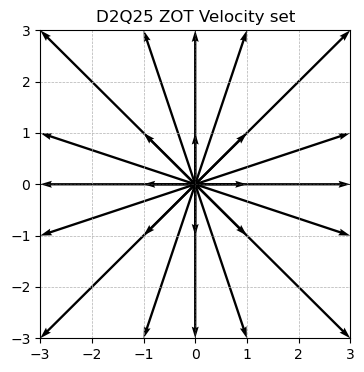

In [43]:
#Velocity Set

origin_x = np.zeros_like(cx)
origin_y = np.zeros_like(cy)

plt.figure(figsize=(4, 4))
plt.quiver(origin_x, origin_y, cx, cy, angles='xy', scale_units='xy', scale=1, color='black')

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.title("D2Q25 ZOT Velocity set")


plt.xticks(np.arange(-3, 4, 1)) 
plt.yticks(np.arange(-3, 4, 1)) 

plt.show()